# **Top-K Backtest**

In [1]:
# stock_features_labeled_10d_df['future_return_10d'] = stock_features_labeled_10d_df['future_return_10d'].clip(-1, 1)
# stock_features_labeled_10d_df = stock_features_labeled_10d_df[stock_features_labeled_10d_df['future_return_10d'].between(-1, 1)]

### Create DuckDB Connection

In [2]:
import duckdb
import os

DB_FOLDER = "database"
DB_PATH = os.path.join(DB_FOLDER, "cse_data.db")

con = duckdb.connect(database=DB_PATH)

In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = con.execute("""SELECT * FROM stocks_10d_prob_table""").fetch_df()
df.head()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index,close_1d,close_3d,close_5d,close_10d,close_20d,close_60d,high_20,low_20,std_vol_20,ret_1,ret_3,ret_5,ret_10,ret_20,ret_60,std_close_5,std_close_10,std_close_20,range_5,atr_14,TR,volume_ratio,volume_z,avg_vol_10,avg_vol_20,liquidity_score,ma_ratio_5,ma_ratio_10,ma_ratio_20,price_position,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d,prob
0,AGSTAR PLC,AGST.N0000,53853,30,9.0,9.1,9.1,8.8,8.9,-0.1,-1.11,2025-12-31,1,9.0,9.4,9.7,9.7,NaN,NaN,10.2,8.8,897592.799434,-0.011111,-0.053191,-0.082474,-0.082474,NaN,NaN,0.311448,0.452278,0.341629,1.1,0.421429,0.3,0.059396,-0.950124,815227.0,906677.80,0.056434,0.975877,0.939810,0.939314,0.117647,0,-0.046793,0.359733,0.000557,-0.011353,0.071429,47.0,11.0,0.235955,1,0.784958
1,AGSTAR PLC,AGST.N0000,218752,63,8.9,9.1,9.2,8.8,9.0,0.1,1.12,2026-01-02,1,8.9,8.8,9.5,9.9,9.5,NaN,10.2,8.8,910267.574294,0.011236,0.022727,-0.052632,-0.090909,-0.052632,NaN,0.228035,0.446716,0.357624,0.9,0.421429,0.4,0.248592,-0.726391,520007.2,879962.20,0.180575,0.997783,0.959488,0.952381,0.176471,0,-0.028353,0.319557,0.000288,-0.017744,0.142857,45.0,11.3,0.255556,1,0.454509
2,AGSTAR PLC,AGST.N0000,1093579,104,9.0,9.2,9.3,9.0,9.2,0.2,2.22,2026-01-05,1,9.0,9.0,9.4,10.2,9.2,NaN,10.2,8.8,908069.681468,0.022222,0.022222,-0.021277,-0.098039,0.000000,NaN,0.148324,0.342540,0.357624,0.6,0.414286,0.3,1.205717,0.205474,460940.7,906994.70,0.247743,1.024499,0.991379,0.973545,0.294118,0,-0.014880,0.248449,0.000095,-0.025263,0.285714,44.0,11.1,0.206522,1,0.665955
3,AGSTAR PLC,AGST.N0000,142539,32,9.3,9.1,9.4,9.1,9.1,-0.2,-2.15,2026-01-08,1,9.2,8.9,8.8,9.7,9.3,NaN,10.2,8.8,908930.111492,-0.010870,0.022472,0.034091,-0.061856,-0.021505,NaN,0.114018,0.311983,0.364764,0.6,0.414286,0.3,0.157326,-0.839967,327016.1,906009.95,0.132149,1.006637,0.986985,0.963983,0.235294,0,-0.007579,0.223556,0.000224,-0.032632,0.214286,43.0,10.7,0.175824,1,0.421828
4,AGSTAR PLC,AGST.N0000,477698,55,9.2,9.3,9.4,9.1,9.2,0.0,0.00,2026-01-12,1,9.1,9.0,9.0,9.6,9.3,NaN,10.2,8.8,913883.598411,0.010989,0.022222,0.022222,-0.041667,-0.010753,NaN,0.130384,0.282056,0.367459,0.6,0.414286,0.3,0.537732,-0.449356,332936.0,888356.65,0.241633,1.013216,1.002179,0.975093,0.294118,0,0.003828,0.223301,0.000115,-0.038271,0.285714,42.0,11.0,0.195652,1,0.492661


#### Calculate daily return
- For each day, calculate the average future 10-day return of the top 10 stocks
- This gives a daily portfolio return, assuming equal weighting of the top 10 stocks

In [4]:
# ✅ Line 1
# con → your database connection (DuckDB / SQLite / etc.)
# .execute(""" ... """) → runs a SQL query
# The result will be converted later to a dataframe

# ✅ Line 2
# WITH → creates a temporary table (CTE = Common Table Expression)
# ranked → name of that temporary table
# 👉 Think:
# "First, create a table called ranked"


# Line 3–4
# SELECT * → take all columns from the original table

# ✅ Line 5
# This is the MOST IMPORTANT LINE
# ROW_NUMBER() → gives ranking numbers: 1, 2, 3, 4...
# OVER (...) → defines how ranking is done
# Inside:
# PARTITION BY date
# 👉 group rows by each date
# ORDER BY prob DESC
# 👉 inside each date, sort by prob (highest first)
# AS rn → store result in column rn

# ✅ Line 6
# Source table
# This contains:
# date
# prob
# future_return_10d
# other features

In [5]:
# Invesement money
invesement= 1

# Connect to an in-memory DuckDB database
con = duckdb.connect(database=DB_PATH)

# Pull Results Back into Python & Equity Curve
# For each date, it ranks the stocks by probability (prob) in descending order
# ROW_NUMBER() assigns 1 to the highest-probability stock, 2 to the next, and so on
# WHERE rn <= 10 AND future_return_10d IS NOT NULL
#       Filters only the top 10 stocks per day (rn <= 10)
#       Ignores rows where the future_return_10d is missing.

daily_returns_df = con.execute("""
    WITH ranked AS (
        SELECT
            *,
        ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rn
        FROM stocks_10d_prob_table
    ),
    topk AS (
        SELECT *
        FROM ranked
        WHERE rn <= 10 AND future_return_10d IS NOT NULL
    )
    SELECT
        date,
        AVG(future_return_10d) AS daily_return
    FROM topk
    GROUP BY date
    ORDER BY date
""").df()

# Compute equity curve in Python
# The total value of your ownership (your money invested + profit/loss)
daily_returns_df['equity'] = (invesement + daily_returns_df['daily_return']).cumprod()

daily_returns_df.tail()

,date,daily_return,equity
27,2026-02-20,0.031955,424.717884
28,2026-02-23,0.144410,486.051372
29,2026-02-24,0.166067,566.768432
30,2026-02-25,0.114227,631.508566
31,2026-02-26,-0.000379,631.269044


### Check all tables in DuckDB

In [6]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
""").fetch_df()

print(tables)

                           table_name
0               stocks_10d_prob_table
1                  stocks_clean_table
2         stocks_features_clean_table
3   stocks_features_labeled_10d_table
4               stocks_features_table
5                 stocks_sorted_table
6                        stocks_table
7             temp_future_price_table
8                temp_liquidity_table
9                  temp_returns_table
10                   temp_trend_table
11                      temp_tr_table
12                     temp_vol_table


### Performance Metrics for top 10 stocks all day
- All the metrics calculated — **Total Return**, **Sharpe Ratio**, **Win Rate**, **Max Drawdown**, etc. — are based only on the top 10 stocks per day that our strategy selected
- This is helpfull to us to get idea about how our model predicted top 10 stock were formanced we can trust thr model
- Not reccomended, but if we insvested in all these 10 stock every day we have thi return

In [7]:
# equity = your portfolio growth over time
# Takes the last value of equity, Subtracts 1 (initial capital)
total_return = (daily_returns_df['equity'].iloc[-1] - invesement ) * 100

# Mean = average of all daily profit/loss
# how much you make per day
avg_return = daily_returns_df['daily_return'].mean()

# Standard deviation of daily returns
# How much your returns move up and down
# High volatility = risky (big swings)   &   Low volatility = stable
# How far returns are spread from average >>> 1% ok more than 5% not good
volatility = daily_returns_df['daily_return'].std()

# Why 252?   Because stock market has about 252 trading days per year.
# We multiply by √252 to convert daily Sharpe → yearly Sharpe
# What Sharpe means : Return per unit of risk
# How much return you are getting for the risk you are taking
# Higher = better
# < 1 → weak , 1–2 → good , 2–3 → strong , 3+ → very strong , 5+ → suspiciously strong
sharpe = avg_return / volatility * (252 ** 0.5)

# Check if each day return > 0 >>> This becomes True (1) or False (0) >>> Take mean
# How often you win
win_rate = (daily_returns_df['daily_return'] > 0).mean() * 100

# Biggest loss from peak to bottom
# cummax() >>> Gets highest equity reached so far
# equity / cummax() >>> How far below peak you are
# - 1 >>> Convert to percentage drop
# .min() >>> Get worst drop
max_drawdown = ((daily_returns_df['equity'] / daily_returns_df['equity'].cummax()) - 1).min()

print(f"Total Return : {total_return:.2f}%")
print(f"Avg Return : {avg_return:.2f}%")
print(f"Volatility : {volatility:.2f}")
print(f"Sharpe Ratio : {sharpe:.3f}")
print(f"Win Rate : {win_rate:.3f}%")
print(f"Max Drawdown : {max_drawdown:.3f}")

Total Return : 63026.90%
Avg Return : 0.23%
Volatility : 0.14
Sharpe Ratio : 26.983
Win Rate : 90.625%
Max Drawdown : -0.131


## Profit / Loss from a prticular day

In [30]:
import numpy as np
import pandas as pd

def evaluate_strategy(start_date):

    # Filter from start date if provided

    df = daily_returns_df.copy()

    df['date'] = pd.to_datetime(df['date'])

    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df['date'] >= start_date].copy()
        
    # Check if filtered data is empty
    if df.empty:
        print(f"No data available from {start_date.date()}")
        return None
        
    total_return = (df['equity'].iloc[-1] - invesement ) * 100
    avg_return = df['daily_return'].mean()

    sharpe = 0
    if volatility != 0:
        sharpe = avg_return / volatility * np.sqrt(252)
        
    win_rate = (df['daily_return'] > 0).mean() * 100
    max_drawdown = ((df['equity'] / df['equity'].cummax()) - 1).min()

    results = {
        "Total Return from ": total_return,
        "Sharpe Ratio": sharpe,
        "Win Rate": win_rate,
        "Max Drawdown": max_drawdown
    }

    return results

# Shwoing
start_date="2025-11-18"
metrics = evaluate_strategy(start_date = start_date)

print("From : ", start_date, " to today\n")

if metrics is not None:
    for k, v in metrics.items():
        if "Return" in k or "Drawdown" in k or "Rate" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:.2f}")
else:
    print("No metrics to show because there is no data for this start date.")

From :  2025-11-18  to today

Total Return from : 7759852.04%
Sharpe Ratio: 26.65
Win Rate: 9354.84%
Max Drawdown: -9.49%


In [35]:
# print(features_labeled_10d_df['future_return_10d'].describe())
df = con.execute("""
    SELECT 
        symbol,
        future_return_10d
    FROM stocks_10d_prob_table
    LIMIT 5
""").fetch_df()

df

,symbol,future_return_10d
0,ABAN.N0000,0.042894
1,ABAN.N0000,-0.068916
2,ABAN.N0000,-0.085536
3,ABAN.N0000,-0.068269
4,ABAN.N0000,-0.084181


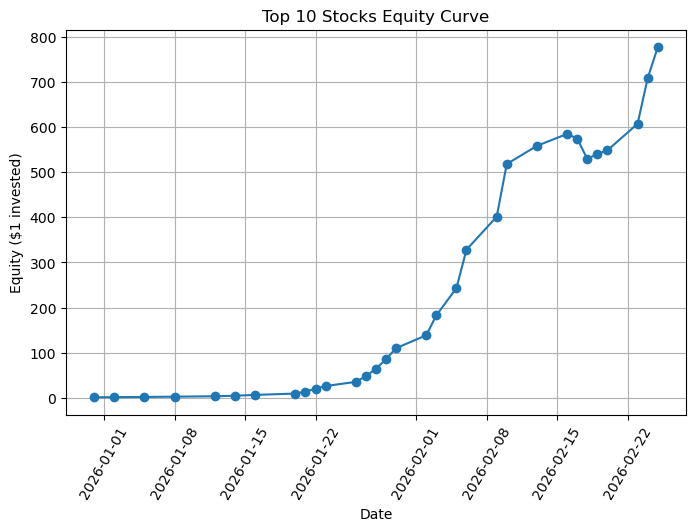

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(daily_returns_df['date'], daily_returns_df['equity'], marker='o')
plt.title("Top 10 Stocks Equity Curve")

plt.xlabel("Date")
plt.ylabel("Equity ($1 invested)")

plt.xticks(rotation=60)

plt.grid(True)
plt.show()

## Top 10 stocks
- List the top 10 stock for each day by "prob" value

In [40]:
# PARTITION BY date >>> This means “start a new ranking for each date.”
# ORDER BY prob DESC >>> Within that date, sort all stocks by model probability (prob) from highest to lowest
# ROW_NUMBER() >>> Assigns a sequential number starting from 1
# The highest probability stock of that day gets rank=1, second highest gets rank=2, …
# WHERE rank <= 10 >>> only want the Top 10 highest probability stocks for each date

topk_companies_df = con.execute("""
    WITH ranked AS (
        SELECT
            date,
            company,
            symbol,
            prob,
            future_return_10d,
            target_buy_10D,
            ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rank
        FROM stocks_10d_prob_table
    )
        SELECT *
        FROM ranked
        WHERE rank <= 10
        ORDER BY date, rank
""").df()

topk_companies_df.tail(20)

,date,company,symbol,prob,future_return_10d,target_buy_10d,rank
390,2026-03-11,ASIRI HOSPITAL HOLDINGS PLC,ASIR.N0000,0.286430,NaN,0,1
391,2026-03-11,COLOMBO CITY HOLDINGS PLC,PHAR.N0000,0.278987,NaN,0,2
392,2026-03-11,COMMERCIAL DEVELOPMENT COMPANY PLC,COMD.N0000,0.260603,NaN,0,3
393,2026-03-11,SOFTLOGIC HOLDINGS PLC,SHL.N0000,0.246698,NaN,0,4
394,2026-03-11,BERUWALA RESORTS PLC,BERU.N0000,0.244907,NaN,0,5
395,2026-03-11,LOLC GENERAL INSURANCE PLC,LGIL.N0000,0.244272,NaN,0,6
396,2026-03-11,MAHAWELI REACH HOTELS PLC,MRH.N0000,0.238500,NaN,0,7
397,2026-03-11,LANKA IOC PLC,LIOC.N0000,0.206973,NaN,0,8
398,2026-03-11,CENTRAL INDUSTRIES PLC,CIND.N0000,0.179274,NaN,0,9
399,2026-03-11,ARPICO INSURANCE PLC,AINS.N0000,0.178006,NaN,0,10


### Close DuckDB Connection

In [41]:
if 'con' in globals():  # Check if connection exists
    try:
        con.close()        # Close it
        print("DuckDB connection closed.")
    except Exception as e:
        print("Error closing DuckDB:", e)
    finally:
        del con             # Delete the variable from memory

DuckDB connection closed.
